In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn import datasets
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_breast_cancer
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
torch.manual_seed(122)
np.random.seed(122)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(30, 4),
            nn.ReLU(),
            nn.Linear(4, 2)
        )

    def forward(self, x):
        return self.net(x)
    
class MLP2(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(30, 8),
            nn.ReLU(),
            nn.Linear(8, 6),
            nn.ReLU(),
            nn.Linear(6, 2)
        )

    def forward(self, x):
        return self.net(x)
    
class Autoencoder(nn.Module):
    def __init__(self, encoding_dim=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(30, 30),
            nn.ReLU(inplace=True),
            nn.Dropout(0.15),
            nn.Linear(30, 15),
            nn.ReLU(inplace=True),
            nn.Dropout(0.15),
            nn.Linear(15, encoding_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 15),
            nn.ReLU(inplace=True),
            nn.Linear(15, 30),
            nn.ReLU(inplace=True),
            nn.Linear(30, 30)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [ ]:


def train_mlp(X_train, y_train, X_val, y_val, epochs=100):
    X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)

    model = MLP().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()

    train_loss_list, val_loss_list = [], []
    train_acc_list, val_acc_list = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()

        # metryki na treningu
        train_preds = outputs.argmax(dim=1)
        train_acc = accuracy_score(y_train_t.cpu().numpy(), train_preds.cpu().numpy())
        train_loss = loss.item()

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_t)
            val_loss = criterion(val_outputs, y_val_t).item()
            val_preds = val_outputs.argmax(dim=1)
            val_acc = accuracy_score(y_val_t.cpu().numpy(), val_preds.cpu().numpy())

        train_loss_list.append(train_loss)
        val_loss_list.append(val_loss)
        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)

        if epoch % 20 == 0:
            print(f"Epoch {epoch:03d} | "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.3f} | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.3f}")

    # === Wykresy ===
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(train_loss_list, label='Train')
    plt.plot(val_loss_list, label='Validation')
    plt.title("Loss MLP")
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(train_acc_list, label='Train')
    plt.plot(val_acc_list, label='Validation')
    plt.title("Accuracy MLP")
    plt.legend()
    plt.show()

    return model


def train_svm(X_train, y_train, X_val, y_val, kernel='linear'):
    clf = SVC(kernel=kernel)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_val)
    acc = accuracy_score(y_val, preds)
    print(f"SVM accuracy: {acc:.3f}")
    return clf


def train_ae_svm(X_train, y_train, X_val, y_val, latent_dim=8, epochs=100):
    X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)

    ae = Autoencoder(latent_dim).to(device)
    optimizer = optim.Adam(ae.parameters(), lr=0.01, weight_decay=1e-5)
    criterion = nn.MSELoss()

    train_loss_list, val_loss_list = [], []

    for epoch in range(epochs):
        ae.train()
        optimizer.zero_grad()
        X_rec = ae(X_train_t)
        train_loss = criterion(X_rec, X_train_t)
        train_loss.backward()
        optimizer.step()

        ae.eval()
        with torch.no_grad():
            X_val_rec = ae(X_val_t)
            val_loss = criterion(X_val_rec, X_val_t)

        train_loss_list.append(train_loss.item())
        val_loss_list.append(val_loss.item())

        if epoch % 20 == 0:
            print(f"Epoch {epoch:03d} | Train Loss: {train_loss.item():.4f} | Val Loss: {val_loss.item():.4f}")

    # Wykres strat
    plt.figure(figsize=(8,4))
    plt.plot(train_loss_list, label="Train")
    plt.plot(val_loss_list, label="Validation")
    plt.title("Autoencoder Reconstruction Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.show()

    # --- Rekonstrukcje ---
    with torch.no_grad():
        Z_train = ae.encoder(X_train_t).cpu().numpy()
        Z_val = ae.encoder(X_val_t).cpu().numpy()
        X_val_rec = ae.decoder(torch.tensor(Z_val, dtype=torch.float32).to(device)).cpu().numpy()

    # --- Klasyfikacja SVM ---
    clf = SVC(kernel='linear')
    clf.fit(Z_train, y_train)
    preds = clf.predict(Z_val)
    acc = accuracy_score(y_val, preds)
    print(f"Autoencoder + SVM accuracy: {acc:.3f}")

    # --- Wizualizacja rekonstrukcji ---
    plt.figure(figsize=(12,4))
    for i in range(min(5, X_val.shape[0])):
        plt.subplot(2,5,i+1)
        plt.bar(range(X_val.shape[1]), X_val[i])
        plt.title("Original")
        plt.subplot(2,5,i+6)
        plt.bar(range(X_val.shape[1]), X_val_rec[i])
        plt.title("Reconstructed")
    plt.tight_layout()
    plt.show()

    return ae, clf


In [5]:
# 1️⃣ Dane – zbiór Iris
iris = load_breast_cancer()
X = iris.data
y = iris.target

In [6]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.9, random_state=42)

===== MLP =====
Epoch 020 | Train Loss: 0.3465 | Train Acc: 0.661 | Val Loss: 0.4212 | Val Acc: 0.624
Epoch 040 | Train Loss: 0.2464 | Train Acc: 1.000 | Val Loss: 0.3373 | Val Acc: 0.938


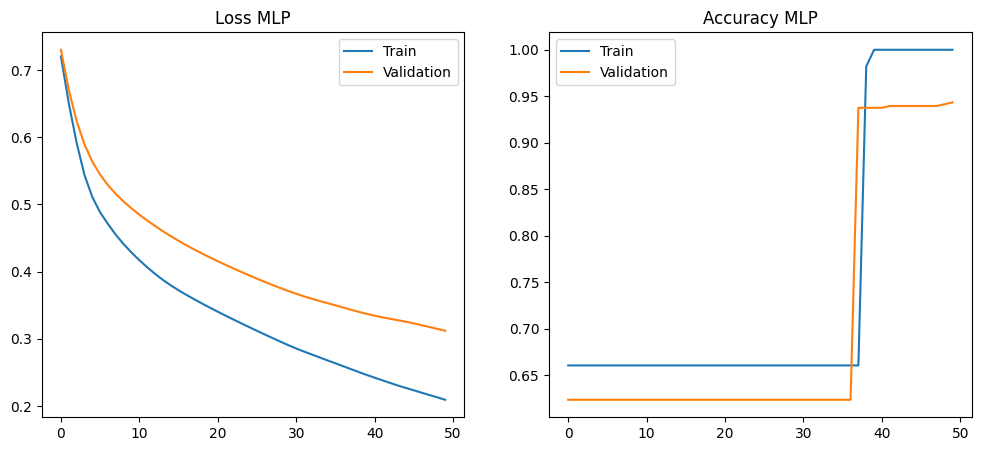

===== SVM =====
SVM accuracy: 0.959
===== Autoencoder + SVM =====
Epoch 000 | Train Loss: 0.8885 | Val Loss: 1.0231
Epoch 020 | Train Loss: 0.5151 | Val Loss: 0.6043
Epoch 040 | Train Loss: 0.4384 | Val Loss: 0.5670
Epoch 060 | Train Loss: 0.4103 | Val Loss: 0.5735
Epoch 080 | Train Loss: 0.3829 | Val Loss: 0.6030


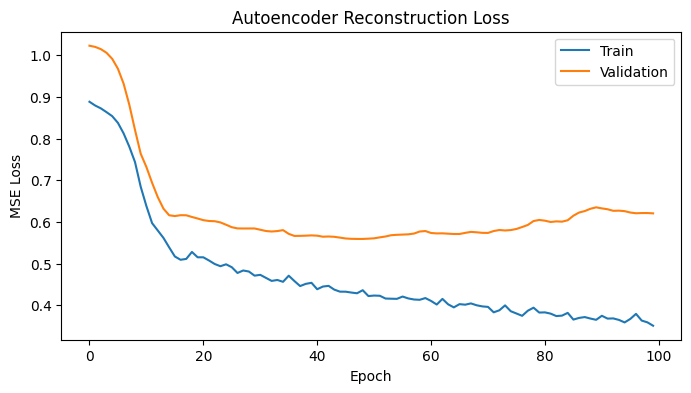

Autoencoder + SVM accuracy: 0.924


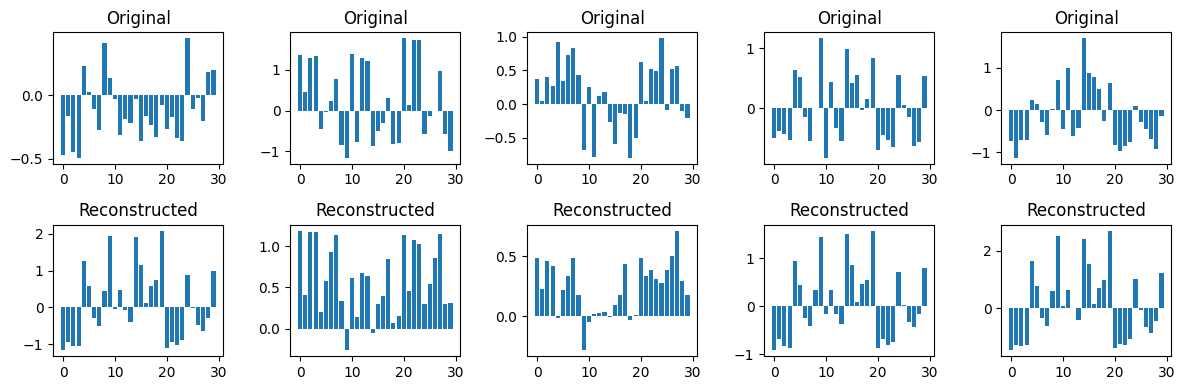

In [8]:

print("===== MLP =====")
mlp_model = train_mlp(X_train, y_train, X_test, y_test, epochs=50)

print("===== SVM =====")
svm_model = train_svm(X_train, y_train, X_test, y_test)

print("===== Autoencoder + SVM =====")
ae_model, ae_svm_model = train_ae_svm(X_train, y_train, X_test, y_test, latent_dim=1, epochs=100)

In [ ]:
def cross_validate_models(X, y, n_splits=5, epochs=200, latent_dim=2):
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    acc_mlp, acc_svm, acc_ae_svm = [], [], []

    fold = 1
    for train_idx, val_idx in kf.split(X, y):
        print(f"\n===== FOLD {fold}/{n_splits} =====")
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # --- MLP ---
        model_mlp = train_mlp(X_train, y_train, X_val, y_val, epochs=epochs)
        X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
        with torch.no_grad():
            preds_mlp = model_mlp(X_val_t).argmax(dim=1).cpu().numpy()
        acc_mlp.append(accuracy_score(y_val, preds_mlp))

        clf_svm = SVC(kernel='linear')
        clf_svm.fit(X_train, y_train)
        preds_svm = clf_svm.predict(X_val)
        acc_svm.append(accuracy_score(y_val, preds_svm))

        ae, clf = train_ae_svm(X_train, y_train, X_val, y_val,
                              latent_dim=latent_dim, epochs=epochs)
        
        with torch.no_grad():
            Z_val = ae.encoder(X_val_t).cpu().numpy()

        preds = clf.predict(Z_val)
        acc_ae = accuracy_score(y_val, preds)

        acc_ae_svm.append(acc_ae)

        fold += 1

    print("\n===== WYNIKI CROSS VALIDATION =====")
    print(f"MLP:           mean={np.mean(acc_mlp):.3f}, std={np.std(acc_mlp):.3f}")
    print(f"SVM:           mean={np.mean(acc_svm):.3f}, std={np.std(acc_svm):.3f}")
    print(f"AE + SVM:      mean={np.mean(acc_ae_svm):.3f}, std={np.std(acc_ae_svm):.3f}")


===== FOLD 1/5 =====
Epoch 020 | Train Loss: 0.1901 | Train Acc: 0.927 | Val Loss: 0.1584 | Val Acc: 0.947
Epoch 040 | Train Loss: 0.0891 | Train Acc: 0.971 | Val Loss: 0.0812 | Val Acc: 0.965
Epoch 060 | Train Loss: 0.0633 | Train Acc: 0.987 | Val Loss: 0.0753 | Val Acc: 0.956
Epoch 080 | Train Loss: 0.0550 | Train Acc: 0.987 | Val Loss: 0.0824 | Val Acc: 0.965
Epoch 100 | Train Loss: 0.0490 | Train Acc: 0.989 | Val Loss: 0.0931 | Val Acc: 0.965
Epoch 120 | Train Loss: 0.0442 | Train Acc: 0.989 | Val Loss: 0.1065 | Val Acc: 0.965
Epoch 140 | Train Loss: 0.0400 | Train Acc: 0.989 | Val Loss: 0.1192 | Val Acc: 0.965
Epoch 160 | Train Loss: 0.0364 | Train Acc: 0.989 | Val Loss: 0.1305 | Val Acc: 0.965
Epoch 180 | Train Loss: 0.0331 | Train Acc: 0.989 | Val Loss: 0.1400 | Val Acc: 0.974
Epoch 200 | Train Loss: 0.0301 | Train Acc: 0.989 | Val Loss: 0.1556 | Val Acc: 0.974


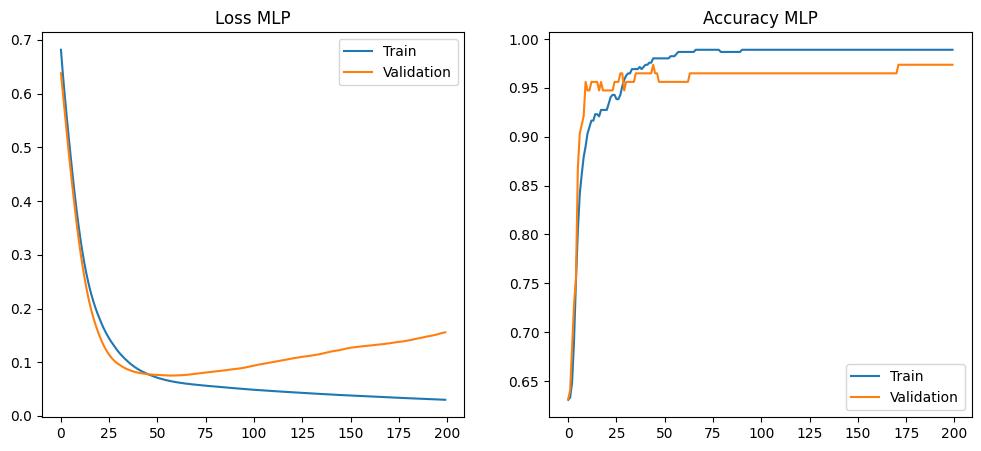

Epoch 000 | Train Loss: 1.0616 | Val Loss: 0.9038
Epoch 020 | Train Loss: 0.6047 | Val Loss: 0.5459
Epoch 040 | Train Loss: 0.4370 | Val Loss: 0.3887
Epoch 060 | Train Loss: 0.3551 | Val Loss: 0.3681
Epoch 080 | Train Loss: 0.3408 | Val Loss: 0.3554
Epoch 100 | Train Loss: 0.3361 | Val Loss: 0.3481
Epoch 120 | Train Loss: 0.3177 | Val Loss: 0.3454
Epoch 140 | Train Loss: 0.3027 | Val Loss: 0.3430
Epoch 160 | Train Loss: 0.3048 | Val Loss: 0.3432
Epoch 180 | Train Loss: 0.3058 | Val Loss: 0.3379


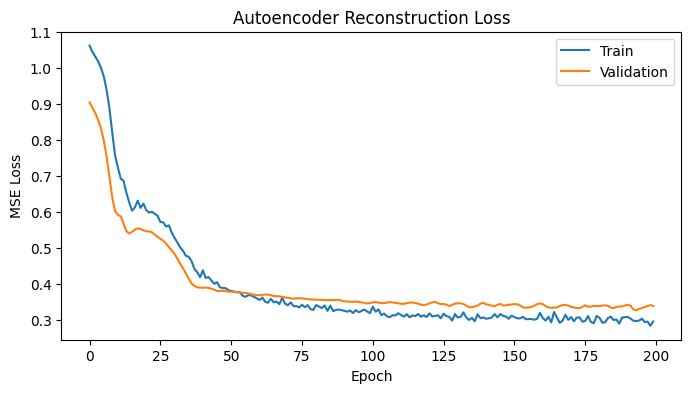

Autoencoder + SVM accuracy: 0.947


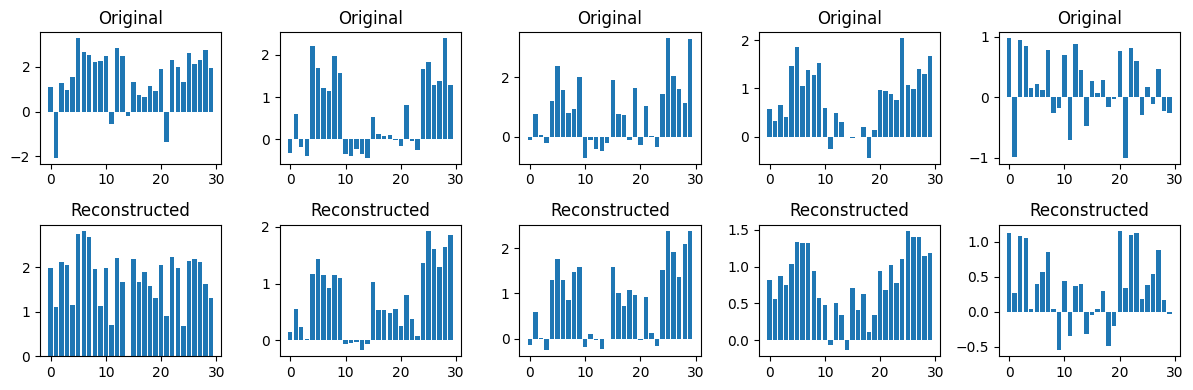


===== FOLD 2/5 =====
Epoch 020 | Train Loss: 0.1795 | Train Acc: 0.947 | Val Loss: 0.1949 | Val Acc: 0.921
Epoch 040 | Train Loss: 0.0826 | Train Acc: 0.978 | Val Loss: 0.1110 | Val Acc: 0.956
Epoch 060 | Train Loss: 0.0627 | Train Acc: 0.985 | Val Loss: 0.0914 | Val Acc: 0.974
Epoch 080 | Train Loss: 0.0546 | Train Acc: 0.989 | Val Loss: 0.0834 | Val Acc: 0.974
Epoch 100 | Train Loss: 0.0483 | Train Acc: 0.989 | Val Loss: 0.0808 | Val Acc: 0.974
Epoch 120 | Train Loss: 0.0432 | Train Acc: 0.993 | Val Loss: 0.0843 | Val Acc: 0.974
Epoch 140 | Train Loss: 0.0396 | Train Acc: 0.993 | Val Loss: 0.0881 | Val Acc: 0.974
Epoch 160 | Train Loss: 0.0367 | Train Acc: 0.993 | Val Loss: 0.0921 | Val Acc: 0.974
Epoch 180 | Train Loss: 0.0339 | Train Acc: 0.993 | Val Loss: 0.0982 | Val Acc: 0.956
Epoch 200 | Train Loss: 0.0314 | Train Acc: 0.993 | Val Loss: 0.1110 | Val Acc: 0.956


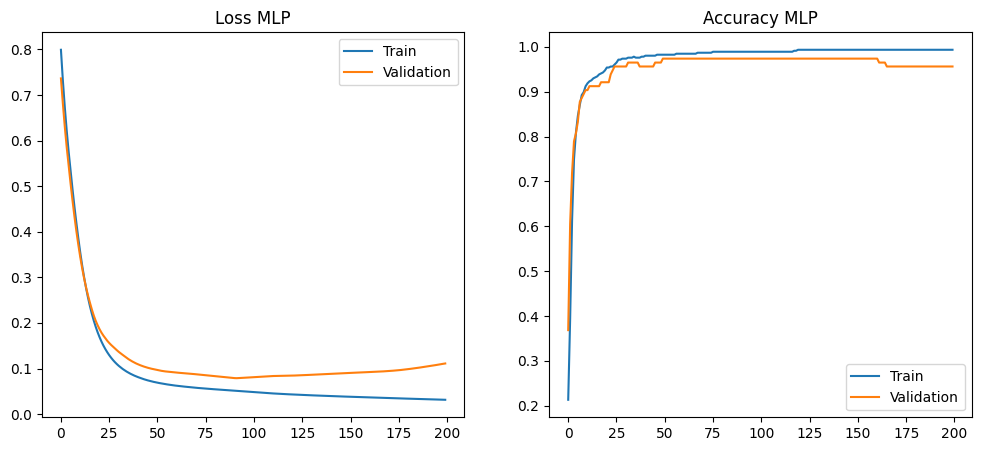

Epoch 000 | Train Loss: 1.0153 | Val Loss: 1.0320
Epoch 020 | Train Loss: 0.6018 | Val Loss: 0.6679
Epoch 040 | Train Loss: 0.4342 | Val Loss: 0.4489
Epoch 060 | Train Loss: 0.3760 | Val Loss: 0.3706
Epoch 080 | Train Loss: 0.3403 | Val Loss: 0.3495
Epoch 100 | Train Loss: 0.3203 | Val Loss: 0.3357
Epoch 120 | Train Loss: 0.3190 | Val Loss: 0.3328
Epoch 140 | Train Loss: 0.3087 | Val Loss: 0.3308
Epoch 160 | Train Loss: 0.2965 | Val Loss: 0.3321
Epoch 180 | Train Loss: 0.3051 | Val Loss: 0.3322


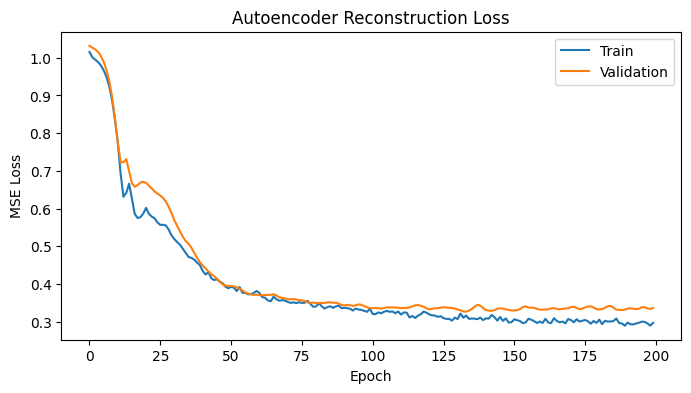

Autoencoder + SVM accuracy: 0.912


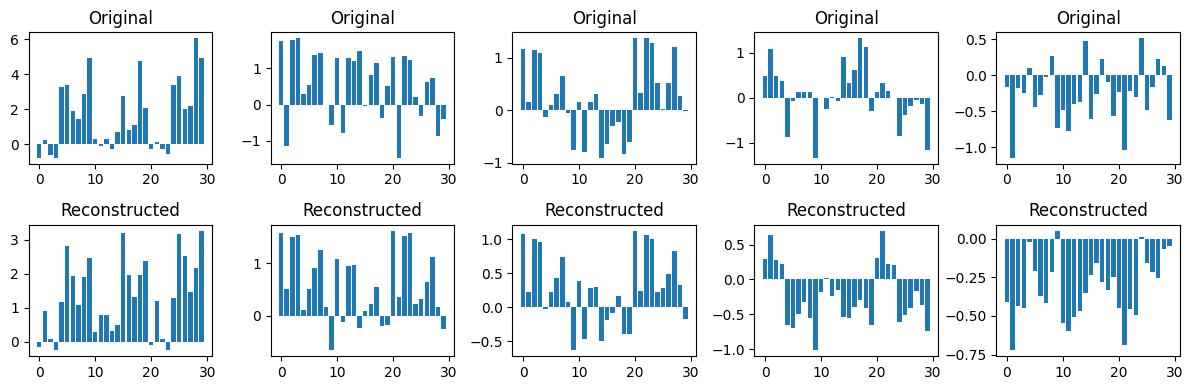


===== FOLD 3/5 =====
Epoch 020 | Train Loss: 0.1780 | Train Acc: 0.921 | Val Loss: 0.1777 | Val Acc: 0.930
Epoch 040 | Train Loss: 0.0793 | Train Acc: 0.980 | Val Loss: 0.1159 | Val Acc: 0.965
Epoch 060 | Train Loss: 0.0527 | Train Acc: 0.985 | Val Loss: 0.1147 | Val Acc: 0.982
Epoch 080 | Train Loss: 0.0399 | Train Acc: 0.987 | Val Loss: 0.1199 | Val Acc: 0.982
Epoch 100 | Train Loss: 0.0336 | Train Acc: 0.989 | Val Loss: 0.1281 | Val Acc: 0.982
Epoch 120 | Train Loss: 0.0297 | Train Acc: 0.993 | Val Loss: 0.1343 | Val Acc: 0.982
Epoch 140 | Train Loss: 0.0269 | Train Acc: 0.996 | Val Loss: 0.1399 | Val Acc: 0.982
Epoch 160 | Train Loss: 0.0248 | Train Acc: 0.996 | Val Loss: 0.1454 | Val Acc: 0.982
Epoch 180 | Train Loss: 0.0230 | Train Acc: 0.996 | Val Loss: 0.1503 | Val Acc: 0.982
Epoch 200 | Train Loss: 0.0215 | Train Acc: 0.996 | Val Loss: 0.1546 | Val Acc: 0.982


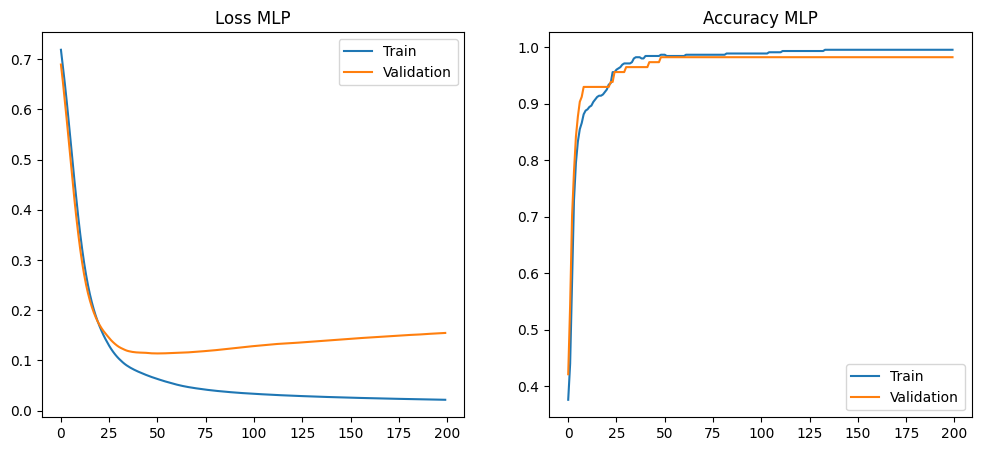

Epoch 000 | Train Loss: 1.0377 | Val Loss: 0.9308
Epoch 020 | Train Loss: 0.6056 | Val Loss: 0.5091
Epoch 040 | Train Loss: 0.4965 | Val Loss: 0.4197
Epoch 060 | Train Loss: 0.3755 | Val Loss: 0.3283
Epoch 080 | Train Loss: 0.3481 | Val Loss: 0.3220
Epoch 100 | Train Loss: 0.3350 | Val Loss: 0.3143
Epoch 120 | Train Loss: 0.3293 | Val Loss: 0.3126
Epoch 140 | Train Loss: 0.3264 | Val Loss: 0.3063
Epoch 160 | Train Loss: 0.3288 | Val Loss: 0.3065
Epoch 180 | Train Loss: 0.3152 | Val Loss: 0.3026


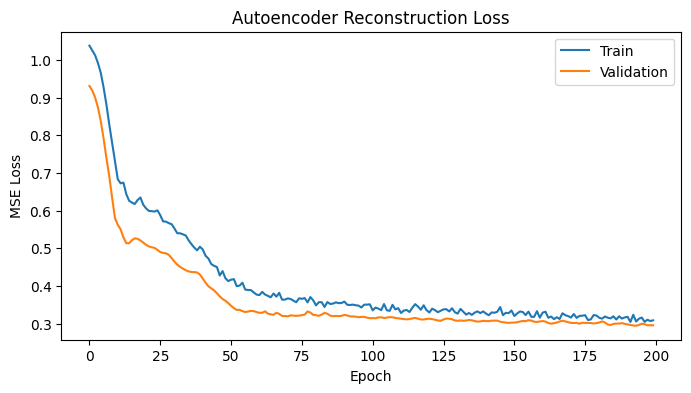

Autoencoder + SVM accuracy: 0.939


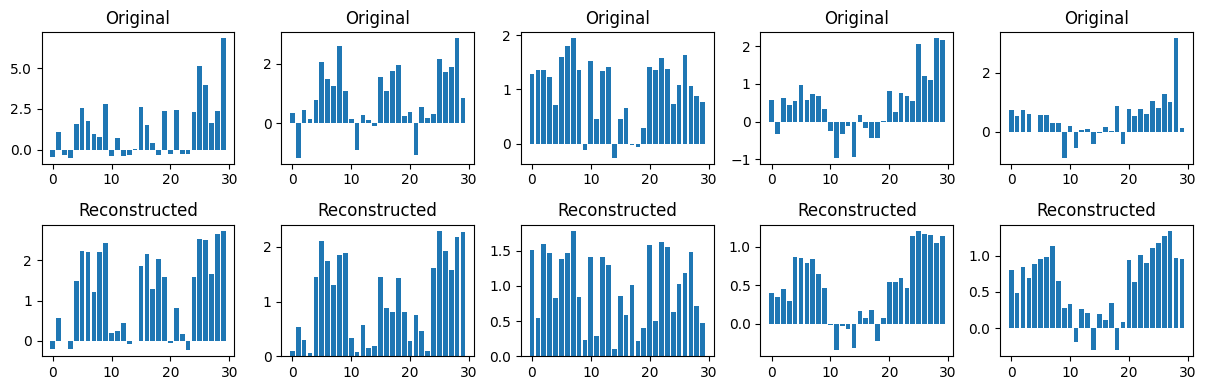


===== FOLD 4/5 =====
Epoch 020 | Train Loss: 0.3059 | Train Acc: 0.945 | Val Loss: 0.3078 | Val Acc: 0.921
Epoch 040 | Train Loss: 0.2175 | Train Acc: 0.976 | Val Loss: 0.2087 | Val Acc: 0.982
Epoch 060 | Train Loss: 0.1678 | Train Acc: 0.982 | Val Loss: 0.1613 | Val Acc: 0.974
Epoch 080 | Train Loss: 0.1374 | Train Acc: 0.982 | Val Loss: 0.1300 | Val Acc: 0.974
Epoch 100 | Train Loss: 0.1165 | Train Acc: 0.982 | Val Loss: 0.1081 | Val Acc: 0.974
Epoch 120 | Train Loss: 0.1016 | Train Acc: 0.982 | Val Loss: 0.0927 | Val Acc: 0.974
Epoch 140 | Train Loss: 0.0904 | Train Acc: 0.982 | Val Loss: 0.0826 | Val Acc: 0.982
Epoch 160 | Train Loss: 0.0814 | Train Acc: 0.982 | Val Loss: 0.0747 | Val Acc: 0.982
Epoch 180 | Train Loss: 0.0735 | Train Acc: 0.987 | Val Loss: 0.0678 | Val Acc: 0.982
Epoch 200 | Train Loss: 0.0669 | Train Acc: 0.987 | Val Loss: 0.0626 | Val Acc: 0.982


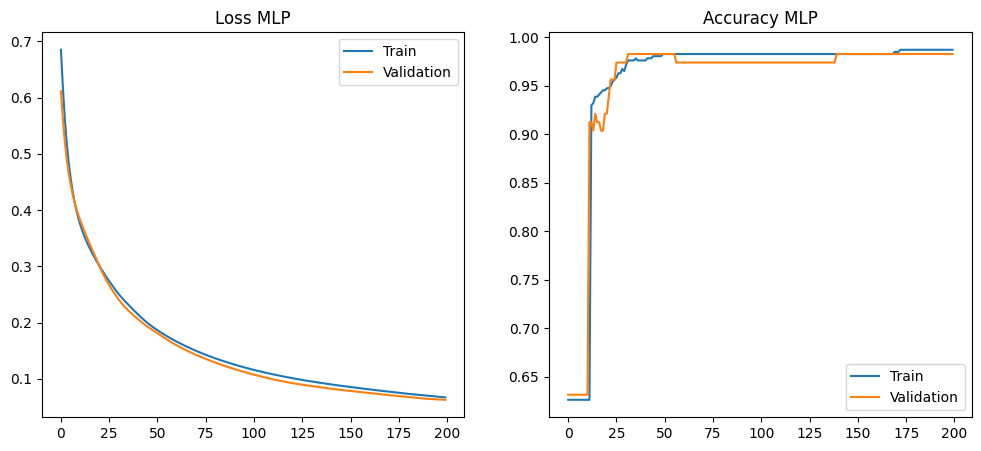

Epoch 000 | Train Loss: 1.0232 | Val Loss: 1.0668
Epoch 020 | Train Loss: 0.5849 | Val Loss: 0.6379
Epoch 040 | Train Loss: 0.4823 | Val Loss: 0.4901
Epoch 060 | Train Loss: 0.3744 | Val Loss: 0.3791
Epoch 080 | Train Loss: 0.3452 | Val Loss: 0.3517
Epoch 100 | Train Loss: 0.3342 | Val Loss: 0.3401
Epoch 120 | Train Loss: 0.3132 | Val Loss: 0.3263
Epoch 140 | Train Loss: 0.3102 | Val Loss: 0.3214
Epoch 160 | Train Loss: 0.3011 | Val Loss: 0.3255
Epoch 180 | Train Loss: 0.3009 | Val Loss: 0.3213


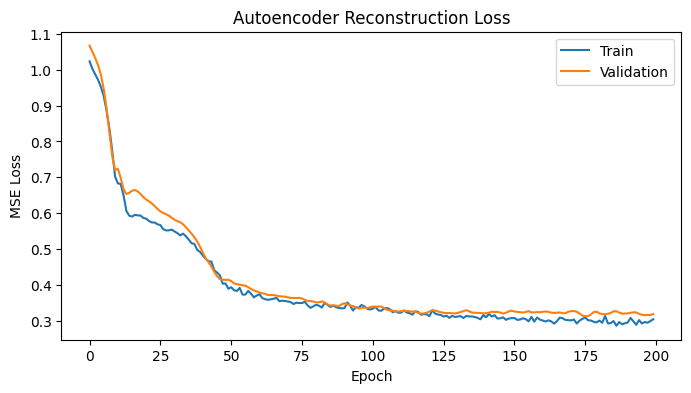

Autoencoder + SVM accuracy: 0.930


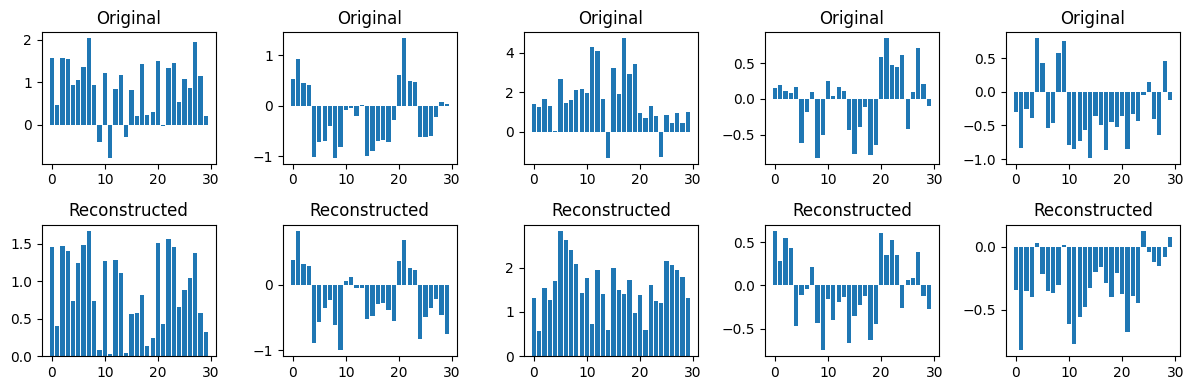


===== FOLD 5/5 =====
Epoch 020 | Train Loss: 0.1652 | Train Acc: 0.950 | Val Loss: 0.1331 | Val Acc: 0.973
Epoch 040 | Train Loss: 0.0847 | Train Acc: 0.974 | Val Loss: 0.0576 | Val Acc: 0.991
Epoch 060 | Train Loss: 0.0682 | Train Acc: 0.985 | Val Loss: 0.0498 | Val Acc: 0.991
Epoch 080 | Train Loss: 0.0593 | Train Acc: 0.987 | Val Loss: 0.0442 | Val Acc: 0.991
Epoch 100 | Train Loss: 0.0519 | Train Acc: 0.989 | Val Loss: 0.0446 | Val Acc: 0.991
Epoch 120 | Train Loss: 0.0454 | Train Acc: 0.987 | Val Loss: 0.0454 | Val Acc: 0.991
Epoch 140 | Train Loss: 0.0396 | Train Acc: 0.989 | Val Loss: 0.0473 | Val Acc: 0.991
Epoch 160 | Train Loss: 0.0346 | Train Acc: 0.991 | Val Loss: 0.0473 | Val Acc: 0.991
Epoch 180 | Train Loss: 0.0305 | Train Acc: 0.991 | Val Loss: 0.0468 | Val Acc: 0.991
Epoch 200 | Train Loss: 0.0271 | Train Acc: 0.991 | Val Loss: 0.0460 | Val Acc: 0.991


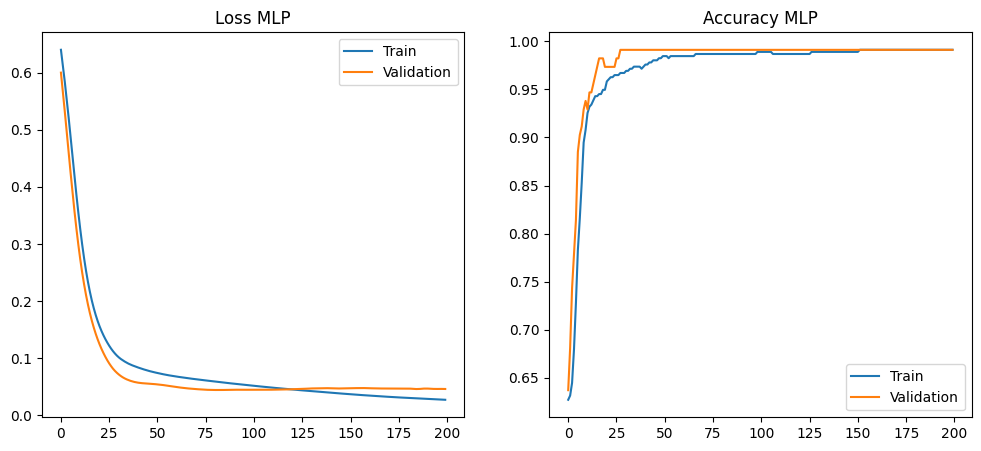

Epoch 000 | Train Loss: 0.9928 | Val Loss: 1.1283
Epoch 020 | Train Loss: 0.5910 | Val Loss: 0.5724
Epoch 040 | Train Loss: 0.4976 | Val Loss: 0.4871
Epoch 060 | Train Loss: 0.4349 | Val Loss: 0.4087
Epoch 080 | Train Loss: 0.3581 | Val Loss: 0.3345
Epoch 100 | Train Loss: 0.3374 | Val Loss: 0.3186
Epoch 120 | Train Loss: 0.3247 | Val Loss: 0.3172
Epoch 140 | Train Loss: 0.3073 | Val Loss: 0.3143
Epoch 160 | Train Loss: 0.2976 | Val Loss: 0.3113
Epoch 180 | Train Loss: 0.3040 | Val Loss: 0.3145


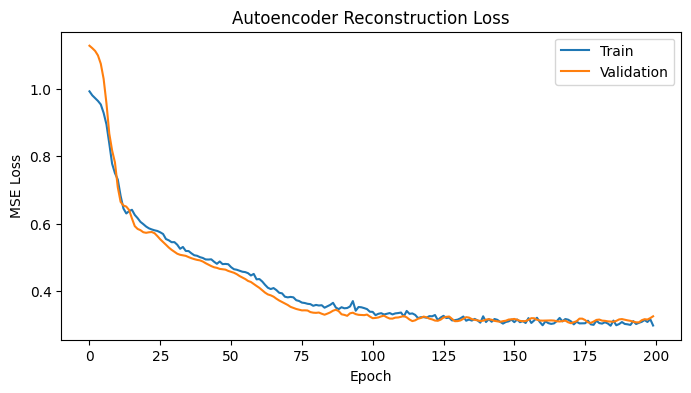

Autoencoder + SVM accuracy: 0.956


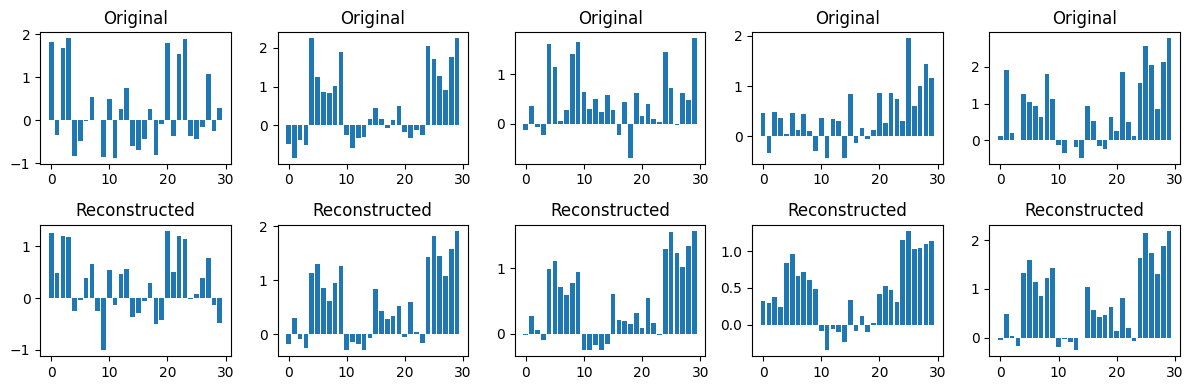


===== WYNIKI CROSS VALIDATION =====
MLP:           mean=0.977, std=0.012
SVM:           mean=0.975, std=0.020
AE + SVM:      mean=0.937, std=0.015


In [17]:
cross_validate_models(X, y, n_splits=5)